# Dyna-Q

## Obiettivo

**Dyna-Q** combina:

1. apprendimento reale tramite Q-learning;
2. un modello tabellare dell'ambiente;
3. aggiornamenti di planning ottenuti simulando transizioni già osservate.

L'esempio usa una piccola linea di cinque stati. L'obiettivo è raggiungere lo stato `4`.

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

In [2]:
class LineWorld:
    """Ambiente lineare con stati 0, 1, 2, 3, 4."""

    def __init__(self, size=5):
        self.size = size
        self.goal = size - 1
        self.state = 0

    def reset(self):
        self.state = 0
        return self.state

    def step(self, action):
        # Azione 0 = sinistra, azione 1 = destra
        if action == 0:
            self.state = max(0, self.state - 1)
        else:
            self.state = min(self.goal, self.state + 1)

        done = self.state == self.goal
        reward = 1.0 if done else 0.0
        return self.state, reward, done

In [3]:
def epsilon_greedy(q_values, epsilon):
    """Sceglie un'azione casuale con probabilità epsilon."""
    if np.random.rand() < epsilon:
        return np.random.randint(len(q_values))
    return int(np.argmax(q_values))

In [4]:
def train_dyna_q(
    episodes=30,
    planning_steps=10,
    alpha=0.1,
    gamma=0.95,
    epsilon=0.1,
):
    env = LineWorld()
    n_states = env.size
    n_actions = 2

    # Tabella Q inizializzata a zero.
    Q = np.zeros((n_states, n_actions))

    # Modello: (stato, azione) -> (stato_successivo, ricompensa)
    model = {}

    steps_per_episode = []

    for episode in range(episodes):
        state = env.reset()
        done = False
        steps = 0

        while not done:
            action = epsilon_greedy(Q[state], epsilon)
            next_state, reward, done = env.step(action)

            # Aggiornamento Q-learning su esperienza reale.
            target = reward
            if not done:
                target += gamma * np.max(Q[next_state])

            Q[state, action] += alpha * (
                target - Q[state, action]
            )

            # Aggiornamento del modello tabellare.
            model[(state, action)] = (next_state, reward, done)

            # Planning: riutilizzo di transizioni già osservate.
            for _ in range(planning_steps):
                simulated_state, simulated_action = random.choice(
                    list(model.keys())
                )
                simulated_next_state, simulated_reward, simulated_done = (
                    model[(simulated_state, simulated_action)]
                )

                simulated_target = simulated_reward
                if not simulated_done:
                    simulated_target += gamma * np.max(
                        Q[simulated_next_state]
                    )

                Q[simulated_state, simulated_action] += alpha * (
                    simulated_target
                    - Q[simulated_state, simulated_action]
                )

            state = next_state
            steps += 1

        steps_per_episode.append(steps)

    return Q, steps_per_episode

## Addestramento con planning

In [5]:
Q, steps = train_dyna_q(planning_steps=10)

print("Tabella Q:")
print(np.round(Q, 3))

policy = np.argmax(Q, axis=1)
print("\nPolitica appresa, 0=sinistra e 1=destra:")
print(policy)

Tabella Q:
[[0.814 0.857]
 [0.814 0.902]
 [0.857 0.95 ]
 [0.902 1.   ]
 [0.    0.   ]]

Politica appresa, 0=sinistra e 1=destra:
[1 1 1 1 0]


## Andamento del numero di passi

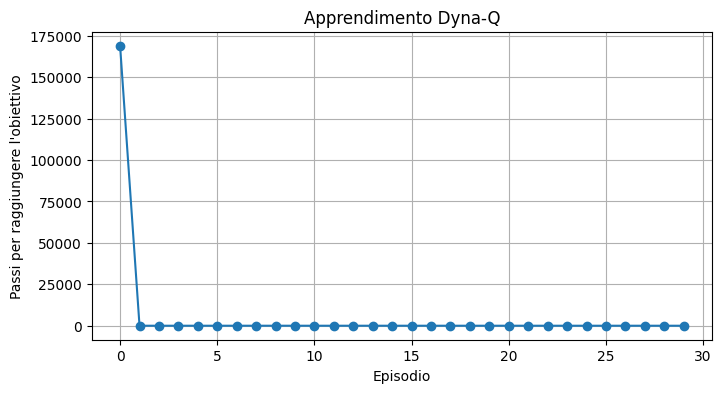

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(steps, marker="o")
plt.xlabel("Episodio")
plt.ylabel("Passi per raggiungere l'obiettivo")
plt.title("Apprendimento Dyna-Q")
plt.grid(True)
plt.show()

## Confronto tra Q-learning puro e Dyna-Q

Impostando `planning_steps=0` si ottiene, di fatto, Q-learning senza planning.

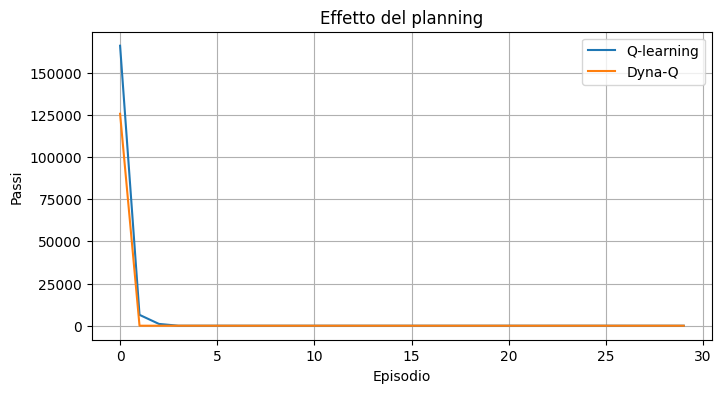

In [7]:
_, steps_q_learning = train_dyna_q(planning_steps=0)
_, steps_dyna_q = train_dyna_q(planning_steps=10)

plt.figure(figsize=(8, 4))
plt.plot(steps_q_learning, label="Q-learning")
plt.plot(steps_dyna_q, label="Dyna-Q")
plt.xlabel("Episodio")
plt.ylabel("Passi")
plt.title("Effetto del planning")
plt.legend()
plt.grid(True)
plt.show()